# Transforms

> Data transformations and augmentations for 2D and 3D BioImages

In [ ]:
#| default_exp transforms

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
import random
from math import ceil
from torch import mean as torchmean, var as torchvar, rand
from inspect import signature, _empty

# =================================
# Scientific / numerical
# =================================
import numpy as np
from numpy import percentile, isscalar, float32 as np_float32
from scipy.ndimage import distance_transform_edt

# =================================
# Computer vision / imaging
# =================================
import cv2
from skimage.transform import resize

# =================================
# MONAI
# =================================
import monai.transforms as mt
from monai.utils.enums import *
from monai.transforms import Transform

# =================================
# fastai
# =================================
from fastai.vision.all import RandTransform, DisplayedTransform, Transform as fastTransform, fastuple

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.data.core import BioImageBase, BioVolume

In [ ]:
#| export
class FunctionTransform(Transform):
    """
    Generic MonaiTransform to apply any NumPy or SciPy function to an image.
    Works with CHW/CDHW arrays or BioImageBase.
    """

    def __init__(self, func,  **func_kwargs):
        self.func = func
        self.func_kwargs = func_kwargs

    def encodes(self, img: np.ndarray):
        if img.ndim >= 3:
            out = np.stack([self.func(img[c], **self.func_kwargs) for c in range(img.shape[0])], axis=0)
        else:
            out = self.func(img, **self.func_kwargs)

        return out

    def encodes(self, img: 'BioImageBase'):
        result = self.encodes(img.numpy())
        return type(img)(result)

In [ ]:
#| export
def _infer_monai_dict_transform(base_cls):
    name = base_cls.__name__

    for suffix in ("d", "D"):
        candidate = name + suffix

        if hasattr(mt, candidate):
            return getattr(mt, candidate)

    raise ValueError(
                f"No dict transform found for "
                f"{name}"
            )

In [ ]:
#| export
class BioTransform(DisplayedTransform):
    _monai_transform = None
    _dict_transform = None

    @classmethod
    def _validate_transform(cls):
        if cls._monai_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_transform`"
            )

    @classmethod
    def _create_transform(cls, *args, **kwargs):
        return cls._monai_transform(*args, **kwargs)

    @classmethod
    def _get_dict_transform(cls):
        return (
            cls._dict_transform
            or _infer_monai_dict_transform(
                cls._monai_transform
            )
        )

    @classmethod
    def _create_dict_transform(
        cls,
        keys,
        *args,
        **kwargs,
    ):
        dict_tfm = cls._get_dict_transform()

        return dict_tfm(
            keys,
            *args,
            **kwargs,
        )

    @classmethod
    def _create_monai_transform(
        cls,
        *args,
        keys=None,
        **kwargs,
    ):
        if keys is not None:
            return cls._create_dict_transform(
                keys,
                *args,
                **kwargs,
            )

        return cls._create_transform(
            *args,
            **kwargs,
        )

In [ ]:
#| export
class MonaiTransform(BioTransform):
    _monai_transform = None
    _dict_transform = None

    def __new__(
        cls,
        *args,
        backend="monai",
        keys=None,
        **kwargs,
    ):
        cls._validate_transform()

        if backend == "monai":
            return cls._create_monai_transform(
                *args,
                keys=keys,
                **kwargs,
            )

        if backend == "fastai":
            return super().__new__(cls)

        raise ValueError(f"Unknown backend: {backend}")

    def __init__(
        self,
        *args,
        keys=None,
        backend="fastai",
        **kwargs,
    ):
        self.transform = self._create_transform(
            *args,
            **kwargs,
        )

        self.dict_transform = (
            self._create_dict_transform(
                keys,
                *args,
                **kwargs,
            )
            if keys is not None
            else None
        )

    def encodes(self, x):
        if isinstance(x, BioImageBase):
            out = self.transform(x)

            return type(x)(
                x=out,
                meta=getattr(out, "meta", x.meta),
            )

        return self.transform(x)

In [ ]:
#| export
def _uniform_sampler(v):

    # range sampling
    if isinstance(v, (tuple, list)) and len(v) == 2:

        a, b = v

        if isinstance(a, int) and isinstance(b, int):
            return np.random.randint(a, b + 1)

        if isinstance(a, (int, float)) and isinstance(b, (int, float)):
            return np.random.uniform(a, b)

        return v

    return v

In [ ]:
#| export
class RandMonaiTransform(BioTransform, RandTransform):

    split_idx = None

    _monai_rand_transform = None
    _monai_det_transform = None

    _rand_kwargs = {}
    _default_kwargs = {}

    # ---------------------------------------------------------
    # Construction
    # ---------------------------------------------------------

    def __new__(
        cls,
        *args,
        backend="monai",
        keys=None,
        **kwargs,
    ):
        cls._validate_transforms()

        cls._monai_transform = (
            cls._monai_rand_transform
        )

        if backend == "monai":

            kwargs = {
                **cls._default_kwargs,
                **kwargs,
            }

            # monai_kwargs = cls._filter_kwargs(
            #     cls._monai_rand_transform,
            #     kwargs,
            # )

            return cls._create_monai_transform(
                *args,
                keys=keys,
                **kwargs,             #   **monai_kwargs,
            )

        if backend == "fastai":
            return super().__new__(cls)

        raise ValueError(
            f"Unknown backend: {backend}"
        )

    def __init__(
        self,
        *args,
        prob=0.1,
        param_sampler=_uniform_sampler,
        backend="fastai",
        **kwargs,
    ):
        store_attr()

        self.p = prob

        self.kwargs = {
            **self._default_kwargs,
            **kwargs,
        }

        self.det_kwargs = self._filter_kwargs(
            self._monai_det_transform,
            self.kwargs,
        )

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------

    @classmethod
    def _validate_transforms(cls):

        if cls._monai_rand_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_rand_transform`"
            )

        if cls._monai_det_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_det_transform`"
            )

    @staticmethod
    def _filter_kwargs(cls, kwargs):

        valid = signature(
            cls.__init__
        ).parameters

        return {
            k: v
            for k, v in kwargs.items()
            if k in valid
        }

    # ---------------------------------------------------------
    # Sampling
    # ---------------------------------------------------------

    # def before_call(self, b, split_idx=0):
    #     pass

    # @dispatch
    def before_call(
        self,
        b: BioImageBase,
        split_idx=0,
    ):
        super().before_call(b, split_idx)

        sampled = {}

        for out_key, spec in self._rand_kwargs.items():

            if isinstance(spec, str):

                sampled[out_key] = (
                    self.param_sampler(
                        self.kwargs[spec]
                    )
                )

            else:

                sampled[out_key] = tuple(
                    self.param_sampler(
                        self.kwargs[k]
                    )
                    for k in spec
                )

        self.sampled_kwargs = {
            **self.det_kwargs,
            **sampled,
        }

    # ---------------------------------------------------------
    # fastai replay path
    # ---------------------------------------------------------

    def encodes(self, x: BioImageBase):

        tfm = self._monai_det_transform(
            **self.sampled_kwargs
        )

        out = tfm(x)

        return type(x)(
            x=out,
            meta=x.meta,
        )

In [ ]:
#| export
class ApplyTo(Transform):
    """
    Apply a transform to a specific element of a tuple.

    Args:
        tfm: the transform or callable to apply
        idx: index of the tuple element to modify (default 0)
    """
    def __init__(self, tfm, idx=0):
        self.tfm = tfm
        self.idx = idx

    def __call__(self, x, **kwargs):
        # Single element case
        if not isinstance(x, (tuple, list)):
            if self.idx != 0:
                raise IndexError(f"Tuple element index {self.idx} out of range for non-tuple input")
            return self.tfm(x, **kwargs)

        # Tuple/list case
        elems = list(x)
        elems[self.idx] = self.tfm(elems[self.idx], **kwargs)
        return tuple(elems)

## Deterministic Transforms

### Size

In [ ]:
#| export
class Resample(MonaiTransform):
    """
    A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.
    
    The `Resample` class does not inherit from MONAI's `Resample` but from `Spacing` and provides a flexible way to adjust the spacing (voxel size) of images by specifying either a sampling factor or explicitly providing new voxel dimensions.
    
    """
    _monai_transform = mt.Spacing

    @classmethod
    def _prepare_backend_args_kwargs(cls, args, kwargs):
        if "sampling" in kwargs and "pixdim" not in kwargs:
            kwargs["pixdim"] = kwargs.pop("sampling")
        return args, kwargs

    def __init__(
        self,
        sampling=None,        # isotropic factor OR pixdim fallback
        keys=None,
        **kwargs
    ):
        """
        If `pixdim` is provided in kwargs, it is used directly.
        Otherwise `sampling` is used as pixdim.
        """

        if 'pixdim' not in kwargs:
            if sampling is None:
                raise ValueError("Provide either `sampling` or `pixdim`")
            kwargs['pixdim'] = sampling

        super().__init__(
            keys=keys,
            **kwargs
        )

In [ ]:
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices, show_image

Input


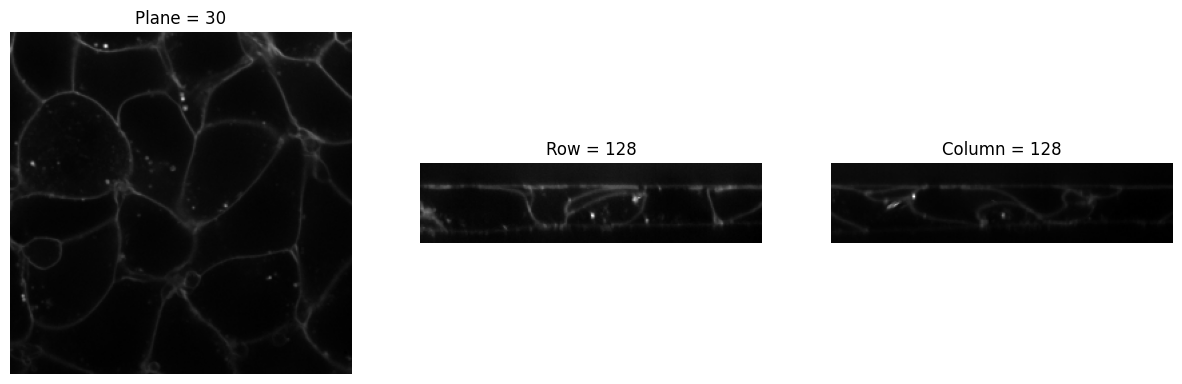

Output type: MetaTensor


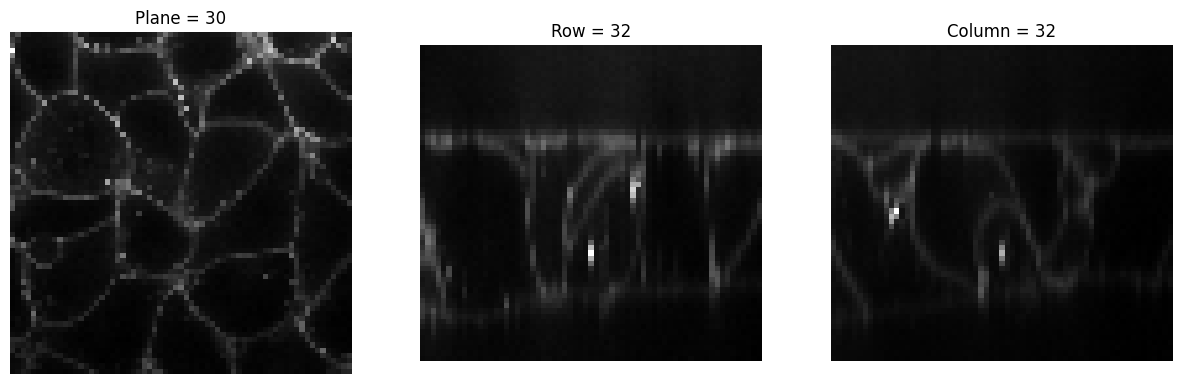

Output type: MetaTensor


/home/bm/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/monai/transforms/spatial/array.py:499: UserWarning: `data_array` is not of type MetaTensor, assuming affine to be identity.
  warnings.warn("`data_array` is not of type MetaTensor, assuming affine to be identity.")


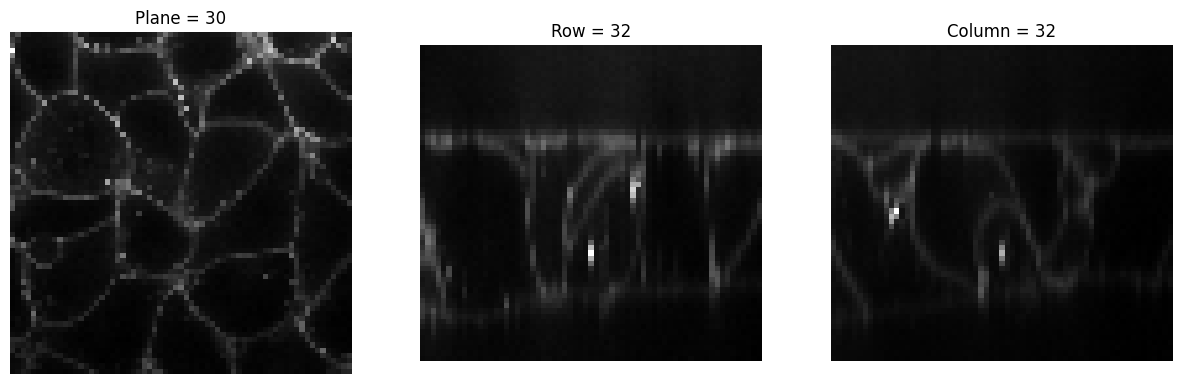

Output type: MetaTensor


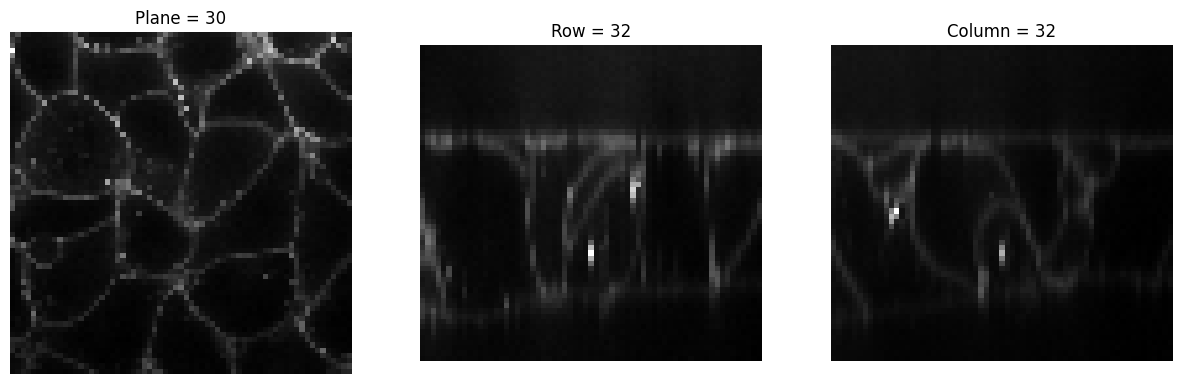

Output type: dict


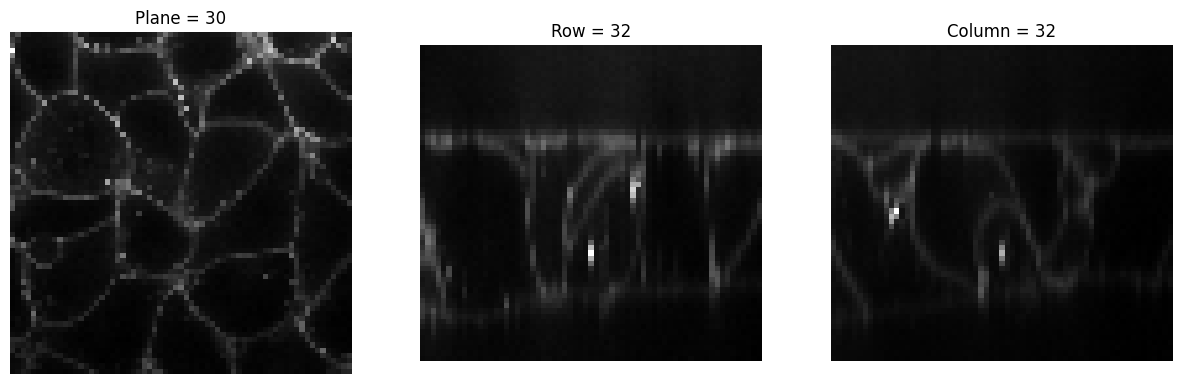

In [ ]:
img = BioVolume(torchTensor(cells3d()[:,0]))
print("Input")
show_slices(img, showlines=False)

img2 = Resample(4)(img)
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

img2 = Resample(4)(cells3d()[:,0])
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

img2 = Resample(4)(MetaTensor(img))
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

img2 = Resample(4, keys=["image"])({ "image": MetaTensor(img) })
print("Output type:", type(img2).__name__)
show_slices(img2['image'], showlines=False)

In [ ]:
#| export 
class Spacing(MonaiTransform):
    """
    A wrapper around MONAI's Spacing transform that supports multiple input types and auto-infers dict transforms.

    """
    _monai_transform = mt.Spacing

    def __init__(
        self,
        pixdim=None,
        keys=None,
        **kwargs
    ):
       
        super().__init__(
            keys=keys,
            pixdim=pixdim,
            **kwargs
        )

In [ ]:
t = Spacing(1)
isinstance(t, Transform)

True

In [ ]:
#| export
class Resize(MonaiTransform):
    """
    A wrapper around MONAI's Resize transform that supports multiple input types and auto-infers dict transforms.

    Args:
        size: output spatial size
        keys: keys for dict transforms (if applicable)
        **kwargs: additional arguments to pass to the underlying transform
    """
    _monai_transform = mt.Resize

    def __init__(
        self,
        spatial_size,        
        keys=None,
        **kwargs
    ):
        super().__init__(
            keys=keys,
            spatial_size=spatial_size,
            **kwargs
        )

torch.Size([60, 256, 256])


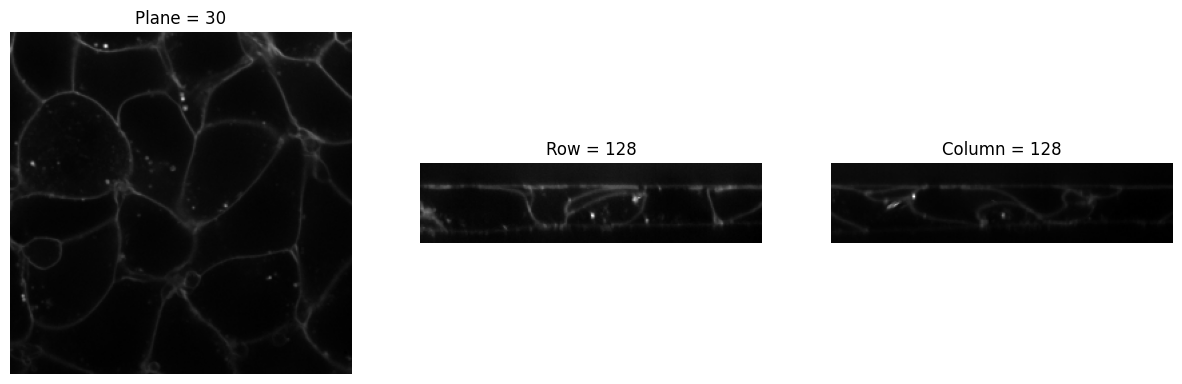

torch.Size([60, 50, 50])


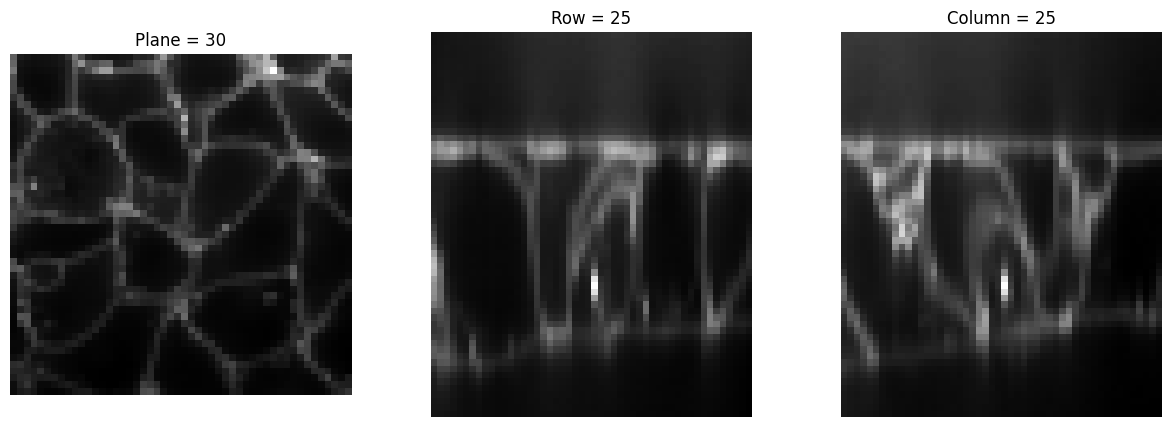

In [ ]:
print(img.size())
show_slices(img, showlines=False)

img2 = Resize((50,50))(img)
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| export
class Crop(MonaiTransform):
    """
    MONAI Crop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Crop*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Crop


In [ ]:
#| export
class SpatialCrop(MonaiTransform):
    """
    MONAI SpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialCrop*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialCrop


In [ ]:
#| export
class CenterSpatialCrop(MonaiTransform):
    """
    MONAI CenterSpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CenterSpatialCrop*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CenterSpatialCrop

    def __init__(
        self,
        roi_size=None,
        keys=None,
        **kwargs,
    ):
        """
        roi_size:
            - int → broadcast to all spatial dims
            - tuple/list → target spatial size
        """

        self.roi_size = roi_size

        super().__init__(
            keys=keys,
            roi_size=roi_size,   # MONAI expects this arg
            **kwargs,
        )

In [ ]:
#| export
class CropForeground(MonaiTransform):
    """
    MONAI CropForeground wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CropForeground*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CropForeground

In [ ]:
#| export
class BoundingRect(MonaiTransform):
    """
    MONAI BoundingRect wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (BoundingRect*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.BoundingRect

In [ ]:
#| export
class CenterScaleCrop(MonaiTransform):
    """
    MONAI CenterScaleCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CenterScaleCrop*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CenterScaleCrop

    def __init__(
        self,
        roi_scale=1.0,
        keys=None,
        **kwargs,
    ):

        self.roi_scale = roi_scale

        super().__init__(
            keys=keys,
            roi_scale=roi_scale, 
            **kwargs,
        )

In [ ]:
#| export

class CropND(fastTransform):
    """
    Crops an ND tensor along a specified dimension.

    This transform crops an ND tensor along specified dimensions, which could be a channel or spatial dimension.
    """
    
    def __init__(self, 
                 slices: list, # List of slice objects or tuples (start, end) for each dimension
                 dims: list = None, # List of dimensions to apply the slices. If None, slices are applied to all dimensions.
                 ):
        self.slices = [slice(*s) if isinstance(s, tuple) else s for s in slices]
        self.dims = dims
        
    def encodes(self, x: BioImageBase):
        """Apply cropping to a BioImageBase object."""
        bioimagetype = type(x)
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return bioimagetype(x[tuple(slices)])
    
    def encodes(self, x: np.ndarray):
        """Apply cropping to a NumPy array."""
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return x[tuple(slices)]

torch.Size([20, 256, 256])


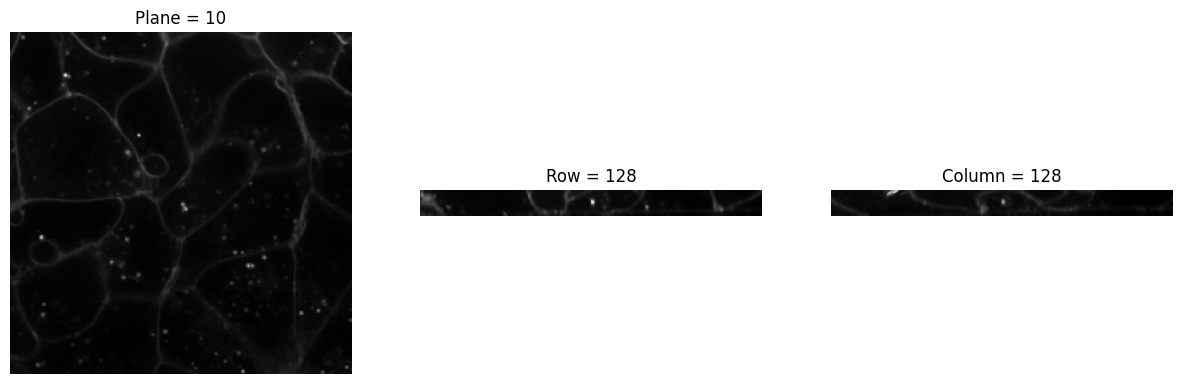

In [ ]:
# Define the slices for cropping
slices = [(30, 50)]

# Create an instance of CropND
crop_transform = CropND(slices=slices)

img3 = crop_transform(img)
print(img3.size())
show_slices(img3, showlines=False)

torch.Size([20, 256, 40])


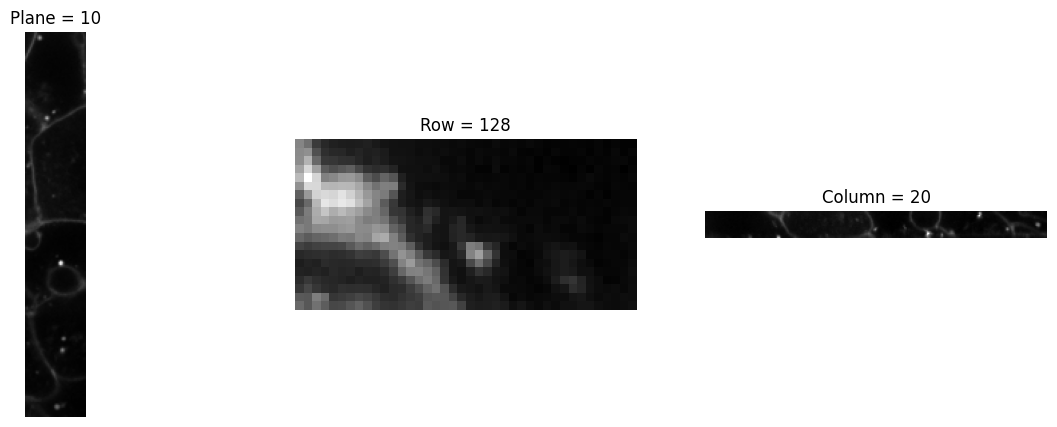

In [ ]:
# Define the slices for cropping
slices = [(30, 50), (0, 40)]
dims = [0, 2]
# Create an instance of CropND
crop_transform = CropND(slices=slices, dims=dims)

img3 = crop_transform(img)
print(img3.size())
show_slices(img3, showlines=False)

In [ ]:
#| export
class Pad(MonaiTransform):
    """
    MONAI Pad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Pad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Pad

In [ ]:
#| export
class SpatialPad(MonaiTransform):
    """
    MONAI SpatialPad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialPad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialPad

    def __init__(
        self,
        spatial_size,
        keys=None,
        **kwargs,
    ):
        self.spatial_size = spatial_size

        super().__init__(
            keys=keys,
            spatial_size=spatial_size, 
            **kwargs,
        )

In [ ]:
#| export
class BorderPad(MonaiTransform):
    """
    MONAI BorderPad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (BorderPad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.BorderPad

    def __init__(
        self,
        spatial_border,
        keys=None,
        **kwargs,
    ):
        self.border_size = spatial_border

        super().__init__(
            keys=keys,
            spatial_border=spatial_border, 
            **kwargs,
        )

In [ ]:
#| export
class DivisiblePad(MonaiTransform):
    """
    MONAI DivisiblePad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (DivisiblePad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.DivisiblePad

    def __init__(
        self,
        k,
        keys=None,
        **kwargs,
    ):

        super().__init__(
            keys=keys,
            k=k, 
            **kwargs,
        )

In [ ]:
#| export
class ResizeWithPadOrCrop(MonaiTransform):

    _monai_transform = mt.ResizeWithPadOrCrop

    def __init__(
        self,
        spatial_size,
        keys=None,
        **kwargs,
    ):
        self.spatial_size = spatial_size

        super().__init__(
            keys=keys,
            spatial_size=spatial_size,
            **kwargs,
        )

### Spatial Orientation & Deformation

In [ ]:
#| export
class Rotate(MonaiTransform):
    """
    MONAI Rotate wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Rotate*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Rotate

    def __init__(
        self,
        angle=0.0,
        keys=None,
        **kwargs,
    ):

        self.angle = angle

        super().__init__(
            keys=keys,
            angle=angle, 
            **kwargs,
        )

In [ ]:
#| export
class Rotate90(MonaiTransform):
    """
    MONAI Rotate90 wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Rotate90*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Rotate90

    def __init__(
        self,
        spatial_axes=(0, 1),
        keys=None,
        **kwargs,
    ):

        self.spatial_axes = spatial_axes

        super().__init__(
            keys=keys,
            spatial_axes=spatial_axes, 
            **kwargs,
        )

In [ ]:
#| export
class Zoom(MonaiTransform):
    """
    MONAI Zoom wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Zoom*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Zoom

    def __init__(
        self,
        zoom=1.0,
        keys=None,
        **kwargs,
    ):

        self.zoom = zoom

        super().__init__(
            keys=keys,
            zoom=zoom, 
            **kwargs,
        )

In [ ]:
#| export
class Flip(MonaiTransform):
    """
    MONAI Flip wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Flip*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """

    _monai_transform = mt.Flip

In [ ]:
#| export
class GridPatch(MonaiTransform):
    """
    MONAI GridPatch wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridPatch*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridPatch

    def __init__(
        self,
        patch_size=None,
        keys=None,
        **kwargs,
    ):

        self.patch_size = patch_size

        super().__init__(
            keys=keys,
            patch_size=patch_size, 
            **kwargs,
        )

In [ ]:
#| export
class GridSplit(MonaiTransform):
    """
    MONAI GridSplit wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridSplit*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridSplit

In [ ]:
#| export
class SpatialResample(MonaiTransform):
    """
    MONAI SpatialResample wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialResample*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialResample

In [ ]:
#| export
class ResampleToMatch(MonaiTransform):
    """
    MONAI ResampleToMatch wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (ResampleToMatch*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.ResampleToMatch

In [ ]:
#| export 
class Orientation(MonaiTransform):
    """
    MONAI Orientation wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Orientation*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Orientation

In [ ]:
#| export
class Affine(MonaiTransform):
    """
    MONAI Affine wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Affine*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Affine

In [ ]:
#| export
class AffineGrid(MonaiTransform):
    """
    MONAI AffineGrid wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (AffineGrid*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.AffineGrid

In [ ]:
#| export
class GridDistortion(MonaiTransform):
    """
    MONAI GridDistortion wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridDistortion*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridDistortion

### Noise & Intensity Shift

In [ ]:
#| export
class GaussianSmooth(MonaiTransform):
    """
    Apply Gaussian smoothing to the input image.

    Parameters
    ----------
    sigma : float or sequence
        Standard deviation of the Gaussian kernel.
    approx : str
        Kernel approximation method.
    """
    _monai_transform = mt.GaussianSmooth

    def __init__(self, sigma=1.0, approx="erf", **kwargs):
        super().__init__(
            sigma=sigma,
            approx=approx,
            **kwargs
        )


class MedianSmooth(MonaiTransform):
    """
    Apply median filtering to the input image.

    Parameters
    ----------
    radius : int or sequence
        Radius of the median filter kernel.
    """
    _monai_transform = mt.MedianSmooth

    def __init__(self, radius=1, **kwargs):
        super().__init__(
            radius=radius,
            **kwargs
        )


class SavitzkyGolaySmooth(MonaiTransform):
    """
    Smooth data using a Savitzky-Golay filter.

    Parameters
    ----------
    window_length : int
        Length of the filter window.
    order : int
        Polynomial order.
    axis : int
        Axis along which smoothing is applied.
    mode : str
        Padding mode.
    """
    _monai_transform = mt.SavitzkyGolaySmooth

    def __init__(self, window_length, order, axis=1, mode="zeros", **kwargs):
        super().__init__(
            window_length=window_length,
            order=order,
            axis=axis,
            mode=mode,
            **kwargs
        )

In [ ]:
#| export
Blur = GaussianSmooth

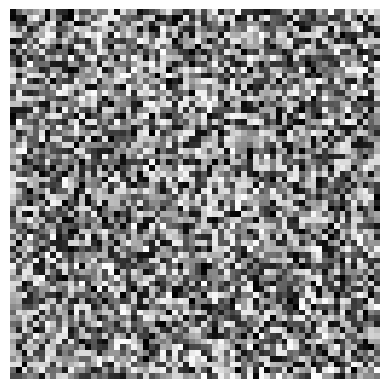

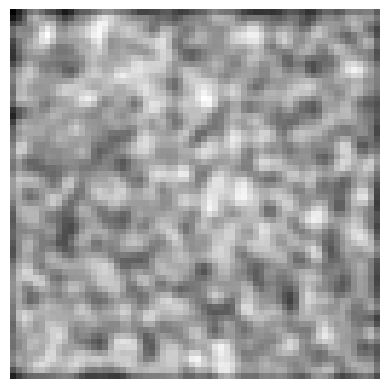

In [ ]:
# Generate a random NumPy array 
random_array = np.random.rand(1, 64, 64)
# Apply Blur transform to the image
blur_transform = Blur() 
blurred_nparray = blur_transform(random_array)

# plot the original image
show_image(random_array)
# Plot the blurred image
show_image(blurred_nparray)

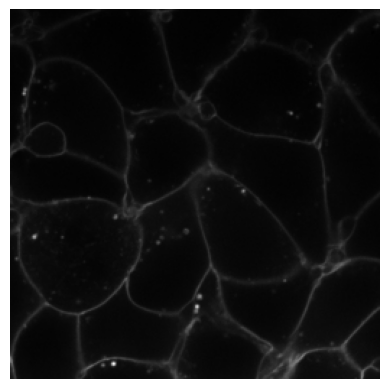

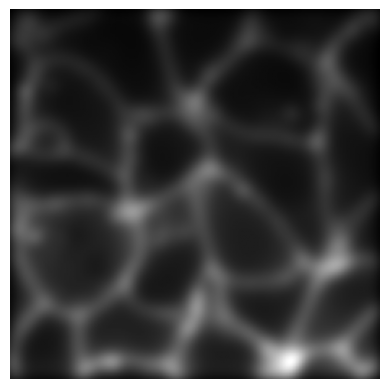

In [ ]:
# Apply Blur transform to the image
blur_transform = Blur(sigma=5) 
sharp_img = blur_transform(img)

# plot the original image
show_image(img)
# Plot the blurred image
show_image(sharp_img)

In [ ]:
#| export
class GaussianSharpen(MonaiTransform):
    """
    Sharpen images using Gaussian filtering.

    Parameters
    ----------
    sigma1 : float or sequence
        Sigma of the first Gaussian kernel.
    sigma2 : float or sequence
        Sigma of the second Gaussian kernel.
    alpha : float
        Sharpening strength.
    approx : str
        Kernel approximation method.
    """
    _monai_transform = mt.GaussianSharpen

    def __init__(self, sigma1=3.0, sigma2=1.0, alpha=30.0, approx="erf", **kwargs):
        super().__init__(
            sigma1=sigma1,
            sigma2=sigma2,
            alpha=alpha,
            approx=approx,
            **kwargs
        )

In [ ]:
# | export

class ShiftIntensity(MonaiTransform):
    """
    Shift the intensity values of the entire image by a constant offset.

    This transform uniformly adds an offset to all pixel/voxel values.

    Parameters
    ----------
    offset : float
        Offset value added to the image intensity.
    safe : bool, optional
        If True, performs safe dtype conversion when overflow occurs.
    """
    _monai_transform = mt.ShiftIntensity

    def __init__(self, offset, safe=False, **kwargs):
        super().__init__(
            offset=offset,
            safe=safe,
            **kwargs
        )


class StdShiftIntensity(MonaiTransform):
    """
    Shift intensity values using the image standard deviation.

    The transform modifies intensity values using:
        v = v + factor * std(v)

    Parameters
    ----------
    factor : float
        Multiplicative factor applied to the image standard deviation.
    nonzero : bool, optional
        If True, compute statistics only on non-zero values.
    channel_wise : bool, optional
        Compute statistics separately for each channel.
    dtype : data-type, optional
        Output data type.
    """
    _monai_transform = mt.StdShiftIntensity
    
    def __init__(self, factor, nonzero=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            factor=factor,
            nonzero=nonzero,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )

### Intensity Normalization

In [ ]:
#| export
def _scale_intensity_range(x,   # The input image to scale.
                           mi,  # The minimum intensity value.
                           ma,  # The maximum intensity value.
                           eps=1e-20, # A small value to prevent division by zero.
                           dtype=np_float32, # The data type to use for the output image.
                           ):
    if dtype is not None:
        x = x.astype(dtype, copy=False)
        mi = dtype(mi) if isscalar(mi) else mi.astype(dtype, copy=False)
        ma = dtype(ma) if isscalar(ma) else ma.astype(dtype, copy=False)
        eps = dtype(eps)
        x = (x - mi) / (ma - mi + eps)
    return x

In [ ]:
#| export
class ScaleImage(Transform):
    """Image normalization."""
    def __init__(x,                 # The input image to scale.
                 min=0.0,           # The minimum intensity value.
                 max=1.0,           # The maximum intensity value.
                 axis=None,         # The axis or axes along which to compute the minimum and maximum values.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply intensity scaling to a BioImageBase object."""
        bioimagetype = type(x)
        y = _scale_intensity_range(x, x.min(), x.max(), eps=self.eps, dtype=self.dtype)
        y *= self.max
        y += self.min
        return bioimagetype(y)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity scaling to a NumPy array."""
        mi = x.min(axis=self.axis, keepdims=True)
        ma = x.max(axis=self.axis, keepdims=True)
        y = (x - mi) / (ma - mi + self.eps)  # Normalize to [0, 1]
        y = y * (self.max - self.min) + self.min  # Scale to [min, max]
        return y.astype(self.dtype)


In [ ]:
#| export
class ScaleImagePercentiles(Transform):
    """Percentile-based image normalization."""
    def __init__(x,                 # The input image to scale.
                 pmin=3,            # The minimum percentile value.
                 pmax=99.8,         # The maximum percentile value.
                 axis=None,         # The axis or axes along which to compute the minimum and maximum values.
                 clip=True,         # If True, clips the output values to the specified range.
                 b_min=0.0,         # The minimum intensity value.
                 b_max=1.0,         # The maximum intensity value.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply percentile-based normalization to a BioImageBase object."""
        bioimagetype = type(x)
        mi = percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = percentile(x, self.pmax, axis=self.axis, keepdims=True)
        if self.clip:
            return bioimagetype(np.clip(_scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype), self.b_min, self.b_max))
        return bioimagetype(_scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype))
    
    def encodes(self, x: np.ndarray):
        """Apply percentile-based normalization to a NumPy array."""
        mi = np.percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = np.percentile(x, self.pmax, axis=self.axis, keepdims=True)
        scaled = (x - mi) / (ma - mi + self.eps)
        scaled = scaled.astype(self.dtype)

        if self.clip:
            return np.clip(scaled, self.b_min, self.b_max)
        return scaled


In [ ]:
#| export
class ScaleImageVariance(fastTransform):
    """
    Scales the intensity variance of an ND image to a target value.
    """
    def __init__(self, target_variance=1.0, # The desired variance for the scaled intensities.
                 ndim=2, # Number of spatial dimensions in the image.
                 ):
        store_attr()
        
    def encodes(self, x: BioImageBase):
        """Apply intensity variance scaling to a BioImageBase object."""
        bioimagetype = type(x)
        # Calculate the current variance of the image intensities
        mean, variance = torchmean(x), torchvar(x)
        if variance == 0:
            return bioimagetype(x)  # Avoid division by zero
        # Calculate the scaling factor based on the ratio of target to current variance
        scale_factor = (self.target_variance / variance).sqrt()
        # Apply the scaling factor to each channel in the image
        if x.ndim == self.ndim + 1:  # Check if it's a multi-channel image (e.g., RGB)
            for i in range(x.shape[0]):
                x[i] = (x[i] - mean) * scale_factor
        else:
            x = (x - mean) * scale_factor
        return bioimagetype(x)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity variance scaling to a NumPy array."""
        mean = np.mean(x)
        variance = np.var(x)
        if variance == 0:
            return x  # Avoid division by zero
        scale_factor = np.sqrt(self.target_variance / variance)
        return (x - mean) * scale_factor


In [ ]:

# Example usage with a random tensor of shape (1, 3, 256, 256)
rand_tensor = BioImageBase(rand(1, 3, 256, 256))

transform = ScaleImageVariance(ndim=4)

# Apply the transform to the tensor
scaled_tensor = transform(rand_tensor)

print('Original Tensor Variance:', rand_tensor.var().item())
print('Scaled Tensor Variance:', scaled_tensor.var().item())


Original Tensor Variance: 0.08316031098365784
Scaled Tensor Variance: 0.9999999403953552


In [ ]:
#| export
class ScaleIntensity(MonaiTransform):
    """
    Scale image intensity to a specified range or by a multiplicative factor.

    Parameters
    ----------
    minv : float, optional
        Minimum output intensity value.
    maxv : float, optional
        Maximum output intensity value.
    factor : float, optional
        Scaling factor applied as v = v * (1 + factor).
    channel_wise : bool, optional
        If True, scale each channel independently.
    dtype : data-type, optional
        Output data type.
    """
    _monai_transform = mt.ScaleIntensity

    def __init__(self, minv=0.0, maxv=1.0, factor=None, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            minv=minv,
            maxv=maxv,
            factor=factor,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


class ScaleIntensityFixedMean(MonaiTransform):
    """
    Scale intensity while preserving the original mean.

    After scaling intensities, the transform shifts the output so that
    the mean intensity remains equal to the input mean.

    Parameters
    ----------
    factor : float
        Scaling factor applied to the image.
    preserve_range : bool
        Clip the output to the original intensity range.
    fixed_mean : bool
        Preserve the original image mean after scaling.
    channel_wise : bool
        Apply scaling independently to each channel.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityFixedMean

    def __init__(self, factor=0, preserve_range=False, fixed_mean=True, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            factor=factor,
            preserve_range=preserve_range,
            fixed_mean=fixed_mean,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


class ScaleIntensityRange(MonaiTransform):
    """
    Linearly rescale intensities from one range to another.

    Parameters
    ----------
    a_min : float
        Minimum value of the input intensity range.
    a_max : float
        Maximum value of the input intensity range.
    b_min : float, optional
        Minimum value of the target intensity range.
    b_max : float, optional
        Maximum value of the target intensity range.
    clip : bool
        Clip intensities after scaling.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityRange

    def __init__(self, a_min, a_max, b_min=None, b_max=None, clip=False, dtype=np.float32, **kwargs):
        super().__init__(
            a_min=a_min,
            a_max=a_max,
            b_min=b_min,
            b_max=b_max,
            clip=clip,
            dtype=dtype,
            **kwargs
        )


class ScaleIntensityRangePercentiles(MonaiTransform):
    """
    Scale intensity values based on image percentiles.

    The transform maps the intensity range defined by two percentiles
    to a target range.

    Parameters
    ----------
    lower : float
        Lower intensity percentile.
    upper : float
        Upper intensity percentile.
    b_min : float
        Target minimum intensity.
    b_max : float
        Target maximum intensity.
    clip : bool
        Clip intensities after scaling.
    relative : bool
        Scale relative to the output range percentiles.
    channel_wise : bool
        Apply independently to each channel.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityRangePercentiles
    _dict_transform = mt.ScaleIntensityRangePercentilesD

    def __init__(self, lower, upper, b_min, b_max, clip=False, relative=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            lower=lower,
            upper=upper,
            b_min=b_min,
            b_max=b_max,
            clip=clip,
            relative=relative,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )

In [ ]:
#| export
class NormalizeIntensity(MonaiTransform):
    """
    Normalize image intensity using mean and standard deviation.

    The transform performs:
        (img - subtrahend) / divisor

    Parameters
    ----------
    subtrahend : float or sequence, optional
        Value subtracted from the image (usually mean).
    divisor : float or sequence, optional
        Value used for division (usually std).
    nonzero : bool
        Normalize only non-zero values.
    channel_wise : bool
        Compute statistics independently per channel.
    dtype : data-type
        Output data type.
    """
    _monai_transform = mt.NormalizeIntensity

    def __init__(self, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            subtrahend=subtrahend,
            divisor=divisor,
            nonzero=nonzero,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


class HistogramNormalize(MonaiTransform):
    """
    Normalize image intensity using histogram equalization.

    Parameters
    ----------
    num_bins : int
        Number of histogram bins.
    min : float
        Minimum intensity value.
    max : float
        Maximum intensity value.
    mask : ndarray, optional
        Optional mask defining valid histogram regions.
    dtype : data-type
        Output data type.
    """
    _monai_transform = mt.HistogramNormalize
    def __init__(self, num_bins=256, min=0, max=255, mask=None, dtype=np.float32, **kwargs):
        super().__init__(
            num_bins=num_bins,
            min=min,
            max=max,
            mask=mask,
            dtype=dtype,
            **kwargs
        )

In [ ]:
#| export
class AdjustContrast(MonaiTransform):
    """
    Adjust image contrast using gamma transformation.

    Each pixel intensity is transformed using a gamma function.

    Parameters
    ----------
    gamma : float
        Gamma value controlling contrast.
    invert_image : bool
        Invert image before applying gamma.
    retain_stats : bool
        Preserve mean and standard deviation after transform.
    """
    _monai_transform = mt.AdjustContrast
    
    def __init__(self, gamma, invert_image=False, retain_stats=False, **kwargs):
        super().__init__(
            gamma=gamma,
            invert_image=invert_image,
            retain_stats=retain_stats,
            **kwargs
        )

### Label Mapping

In [ ]:
#| export
class RelabelInstances(Transform):
    """Remap instance mask labels to consecutive integers.
    
    Example:
        [0, 1, 3, 7, 18] → [0, 1, 2, 3, 4]
    """

    def __init__(self,
                 background=0,        # Label considered background
                 dtype=np.int32,      # Output dtype
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)

        arr = np.asarray(x)

        unique_labels = np.unique(arr)
        fg_labels = unique_labels[unique_labels != self.background]

        new_ids = np.arange(1, len(fg_labels) + 1, dtype=self.dtype)
        mapping = dict(zip(fg_labels, new_ids))

        y = np.full_like(arr, self.background, dtype=self.dtype)

        for old_id, new_id in mapping.items():
            y[arr == old_id] = new_id

        return bioimagetype(y)
    
    def encodes(self, x: np.ndarray):
        """Relabel instance mask (NumPy array)."""

        x = np.asarray(x)

        unique_labels = np.unique(x)

        # Remove background from remapping
        fg_labels = unique_labels[unique_labels != self.background]

        # Create mapping dictionary
        new_ids = np.arange(1, len(fg_labels) + 1, dtype=self.dtype)
        mapping = dict(zip(fg_labels, new_ids))

        # Initialize output
        y = np.full_like(x, self.background, dtype=self.dtype)

        # Apply mapping
        for old_id, new_id in mapping.items():
            y[x == old_id] = new_id

        return y

In [ ]:
#| export
class InstanceToMaskAndDistance(fastTransform):
    """
    Converts a single-channel instance segmentation map (CHW or CDHW)
    into a 2-channel image:

    Channel 0: Binary mask (instances > 0)
    Channel 1: Distance transform (inside objects)
    """

    def __init__(self, 
                 normalize=True,     # Normalize distance map per instance
                 ):
        store_attr()

    def encodes(self, img: BioImageBase):
        return type(img)(self._process(img.numpy()))

    def encodes(self, img: np.ndarray):
        return self._process(img)

    def _process(self, img: np.ndarray):
        """
        img: (C,H,W) or (C,D,H,W) with C=1
        """
        assert img.shape[0] == 1, "Input must have exactly 1 channel"

        inst = img[0]
        binary = (inst > 0).astype(np.uint8)

        # distance inside objects
        dist = distance_transform_edt(binary)

        if self.normalize and dist.max() > 0:
            dist = dist / dist.max()

        # stack channels
        out = np.stack([binary, dist], axis=0)

        return out.astype(np.float32)

In [ ]:
md = InstanceToMaskAndDistance()(np.random.rand(1, 33, 90, 90))
test_eq(md.shape, (2, 33, 90, 90))

In [ ]:
#| export
class ComputeHoVerMaps(MonaiTransform):
    """
    Compute HoVer maps (horizontal and vertical distance maps) from instance masks.

    These maps are commonly used in HoVer-Net based nucleus segmentation.

    Parameters
    ----------
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ComputeHoVerMaps

### Thresholding / Masking

In [ ]:
#| export
class ThresholdIntensity(MonaiTransform):
    """
    Filter image intensities using a threshold.

    Values above or below the threshold are replaced with a constant value.

    Parameters
    ----------
    threshold : float
        Intensity threshold.
    above : bool
        If True, filter values above the threshold.
    cval : float
        Fill value for filtered pixels.
    """
    _monai_transform = mt.ThresholdIntensity

    def __init__(self, threshold, above=True, cval=0.0, **kwargs):
        super().__init__(
            threshold=threshold,
            above=above,
            cval=cval,
            **kwargs
        )


class MaskIntensity(MonaiTransform):
    """
    Mask intensity values using a binary mask.

    Pixels outside the mask are set to zero.

    Parameters
    ----------
    mask_data : ndarray, optional
        Binary mask defining valid regions.
    select_fn : callable, optional
        Function defining valid mask values.
    """
    _monai_transform = mt.MaskIntensity

    def __init__(self, mask_data=None, select_fn=None, **kwargs):
        super().__init__(
            mask_data=mask_data,
            select_fn=select_fn,
            **kwargs
        )


class ForegroundMask(MonaiTransform):
    """
    Generate a binary foreground mask based on image intensity.

    Parameters
    ----------
    threshold : int, float, callable, or str
        Threshold method or value.
    hsv_threshold : optional
        Threshold defined in HSV space.
    invert : bool
        Invert image before thresholding.
    """
    _monai_transform=mt.ForegroundMask

    def __init__(self, threshold="otsu", hsv_threshold=None, invert=False, **kwargs):
        super().__init__(
            threshold=threshold,
            hsv_threshold=hsv_threshold,
            invert=invert,
            **kwargs
        )

### Color space

In [ ]:
#| export
from skimage.color import rgb2hed, hed2rgb

In [ ]:
#| export
class RGB2HED(Transform):
    """Convert RGB images to HED color space."""
    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)
        x = ScaleIntensity()(x).numpy()  # Ensure the image is scaled to [0, 1] before conversion
        ihc = rgb2hed(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for rgb2hed, then back to (C, H, W)
        return bioimagetype(torchTensor(ihc))  # Return the converted image with the same type as the input
    
    def encodes(self, x: np.ndarray):
        x = ScaleIntensity()(x)  # Ensure the image is scaled to [0, 1] before conversion
        return rgb2hed(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for rgb2hed, then back to (C, H, W)

In [ ]:
#| export
class HED2RGB(Transform):
    """Convert HED images back to RGB color space."""
    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)
        x = ScaleIntensity()(x).numpy()  # Ensure the image is scaled to [0, 1] before conversion
        rgb = hed2rgb(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for hed2rgb, then back to (C, H, W)
        return bioimagetype(torchTensor(rgb))  # Return the converted image with the same type as the input
    
    def encodes(self, x: np.ndarray):
        x = ScaleIntensity()(x)  # Ensure the image is scaled to [0, 1] before conversion
        return hed2rgb(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for hed2rgb, then back to (C, H, W)

## Data Augmentation

### Size

In [ ]:
#| export
def _process_sz(size, ndim=3):
    if isinstance(size,int): 
        size=(size,)*ndim
    return fastuple(size)

def _get_sz(x):
    if isinstance(x, tuple): x = x[0]
    if not isinstance(x, torchTensor): return fastuple(x.shape[1:])
    return fastuple(getattr(x, 'img_size', getattr(x, 'sz', (x.shape[1:])))) # maybe it should swap x and y axes 

In [ ]:
#| export
def _compute_roi_intervals(img_size, roi_size):
    intervals = []
    for img_dim, roi_dim in zip(img_size, roi_size):
        if img_dim > roi_dim:
            start = roi_dim // 2
            end = img_dim - (roi_dim - roi_dim // 2)
            intervals.append((start, end))
        else:
            intervals.append((0, 0))  # No valid interval if ROI is larger than image dimension
    return intervals

In [ ]:
#| hide
# Define a random tensor
orig_size = (10, 8)
rand_tensor = rand(3, *orig_size)  # Random tensor with shape (3, 10, 8)

test_eq((3,)*3,_process_sz(3,ndim=3))
test_eq(orig_size,_get_sz((rand_tensor, rand_tensor)))

In [ ]:
#| export
class RandCrop(RandMonaiTransform):
    """
    Randomly crop a region from the input image.

    Parameters
    ----------
    spatial_size : sequence
        Desired output spatial size (e.g., (height, width)).
    keys : list of str, optional
        Keys to apply the transform to when using with dictionaries.
    """
    _monai_rand_transform = mt.RandSpatialCrop
    _monai_det_transform = mt.SpatialCrop

    _val_transform = CenterSpatialCrop

    def __init__(self, roi_size, 
                 keys=None, 
                 **kwargs
                 ):
        self.roi_size = roi_size

        super().__init__(
            keys=keys,
            roi_size=roi_size, 
            **kwargs,
        )

        self.kwargs.pop("prob", None)  

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):

        self.sampled_kwargs = {}

        im_size = _get_sz(b)

        if self.kwargs.get("random_size", None) is not None:
            max_roi_size = self.kwargs.get("max_roi_size", im_size)
            roi_interval = [
                (min_size,max_size+1) 
                for min_size,max_size in zip(
                    self.roi_size, max_roi_size
                    )
                ]
            sampled_roi_size = tuple(
                self.param_sampler(v) for v in roi_interval
            )
            self.sampled_kwargs["roi_size"] = sampled_roi_size
        else:
            sampled_roi_size = self.roi_size

        center_intervals = _compute_roi_intervals(im_size, sampled_roi_size)

        self.sampled_kwargs["roi_center"] = tuple(
            self.param_sampler(v) for v in center_intervals
        )

        # merge sampled into deterministic params
        self.sampled_kwargs = {
            **self.det_kwargs,
            **self.sampled_kwargs,
        }

In [ ]:
im = cells3d()[30,1:].astype(float)

torch.Size([1, 57, 65])


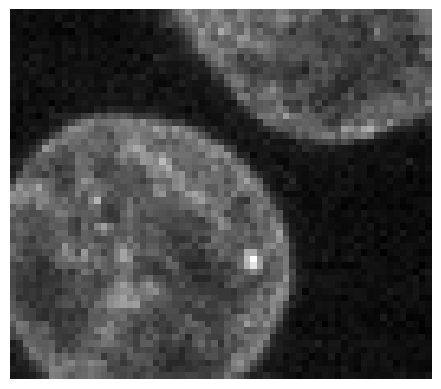

In [ ]:
tfm = RandCrop(roi_size=(50, 50), max_roi_size=(60,70), random_size=True)
im2 = tfm(im)
print(im2.shape)
show_image(im2)

torch.Size([1, 114, 78])


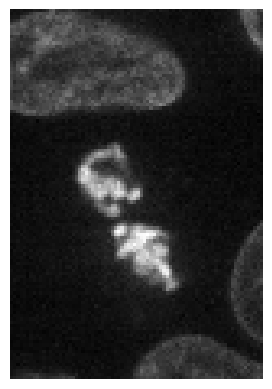

In [ ]:
tfm = RandCrop(roi_size=(50, 50), random_size=True)
im2 = tfm(BioImageBase(im))
print(im2.shape)
show_image(im2)

In [ ]:
#| export
RandSpatialCrop = RandCrop

In [ ]:
#| export

class RandCrop2D(RandTransform):
    """
    Randomly crops a 2D image to a specified size.

    This transform randomly crops a 2D image to a specified size during training and 
    performs a center crop during validation.
    """
    split_idx,order = None,1
    def __init__(self, 
        size:int|tuple, # Size to crop to, duplicated if one value is specified
        lazy = False,   # a flag to indicate whether this transform should execute lazily or not. Defaults to False
        **kwargs
    ):
        size = _process_sz(size, ndim=2)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, 
        b, 
        split_idx:int # Index of the train/valid dataset
    ):
        "Randomly positioning crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx: self.ctr = (self.orig_sz)//2
        else:
            wd = self.orig_sz[0] - self.size[0]
            hd = self.orig_sz[1] - self.size[1]
            w_rand = (wd, -1) if wd < 0 else (0, wd)
            h_rand = (hd, -1) if hd < 0 else (0, hd)
            self.ctr = fastuple(random.randint(*w_rand)+self.size[0]//2, random.randint(*h_rand)+self.size[1]//2)

    def encodes(self, x: BioImageBase):
        """Apply spatial cropping to a BioImageBase object."""
        bioimagetype = type(x)
        return bioimagetype(mt.SpatialCrop(roi_center=self.ctr, roi_size=self.size, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        half_w, half_h = self.size[0] // 2, self.size[1] // 2
        cx, cy = self.ctr

        # Calculate crop region
        x_start, x_end = max(cx - half_w, 0), min(cx + half_w, x.shape[0])
        y_start, y_end = max(cy - half_h, 0), min(cy + half_h, x.shape[1])

        return x[x_start:x_end, y_start:y_end]

In [ ]:
#| export

class RandCropND(RandTransform):
    """
    Randomly crops an ND image to a specified size.

    This transform randomly crops an ND image to a specified size during training and performs
    a center crop during validation. It supports both 2D and 3D images and videos, assuming
    the first dimension is the batch dimension.
    """

    split_idx,order = None,1
        
    def __init__(self, size: int | tuple, # Size to crop to, duplicated if one value is specified
                 lazy = False,            # a flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        "Randomly position crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx:
            self.tl = tuple((osz - sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
            self.br = tuple((osz + sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
        else:
            tl = [] # top-left corner
            br = [] # bottom-right corner
            # Calculate top-left and bottom-right corner coordinates for random crop
            for osz, sz in zip(self.orig_sz, self.size):
                w_dif = osz - sz
                if w_dif < 0:
                    w_rand = (0, 0) # No random cropping if input size is smaller than crop size
                    sz = osz # Adjust crop size to match input size
                else:
                    w_rand = (0, w_dif)
                rnd = random.randint(*w_rand)
                tl.append(rnd)
                br.append(rnd + sz)
            self.tl = fastuple(*tl)
            self.br = fastuple(*br)

    def encodes(self, x:BioImageBase):
        "Apply spatial crop transformation to the input image."
        bioimagetype = type(x)
        return bioimagetype(mt.SpatialCrop(roi_start=self.tl, roi_end=self.br, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        slices = tuple(slice(t, b) for t, b in zip(self.tl, self.br))
        return x[slices]
    

In [ ]:
# Define a random tensor
orig_size = (65, 65)
rand_tensor = BioImageBase(rand(8, *orig_size))

for i in range(100):
    test_eq((8,64,64),RandCropND((64,64))(rand_tensor).shape)

### Spatial Orientation & Deformation

In [ ]:
class RandRotate(RandMonaiTransform):

    _monai_rand_transform = mt.RandRotate
    _monai_det_transform = mt.Rotate

    _rand_kwargs = {'angle': ['range_x', 'range_y', 'range_z']}
    _default_kwargs = {'range_x': 0, 'range_y': 0, 'range_z': 0}

    def encodes(self, x: BioImageBase):

        # CYX → MONAI expects 1 value
        if x.ndim == 3:
            angle = self.sampled_kwargs["angle"]
            self.sampled_kwargs["angle"] = angle[0]

        tfm = self._monai_det_transform(**self.sampled_kwargs)
        out = tfm(x)

        return type(x)(x=out, meta=x.meta)

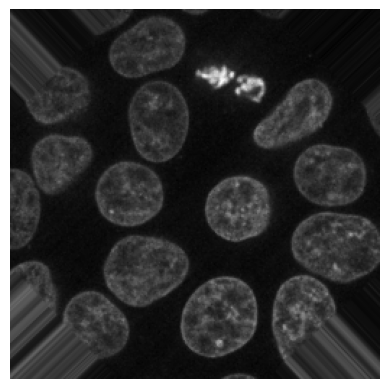

In [ ]:
tfm = RandRotate(range_x=(-30, 30), keep_size=True, prob=1)
show_image(tfm(BioImageBase(im)));

In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = BioImageBase(rand(*orig_size))

In [ ]:
print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandRotate(prob=1, range_x=1)(rand_tensor))

orig tensor:  metatensor([[[0.2258, 0.0028, 0.4504, 0.1576],
         [0.0048, 0.4848, 0.7380, 0.1217],
         [0.1700, 0.1241, 0.3883, 0.5348],
         [0.0303, 0.7965, 0.6709, 0.7718]]]) 

metatensor([[[0.2014, 0.4165, 0.1869, 0.3050],
         [0.0899, 0.5263, 0.5182, 0.5656],
         [0.0666, 0.2548, 0.3584, 0.6670],
         [0.0967, 0.1519, 0.6306, 0.7266]]])
metatensor([[[0.2414, 0.4040, 0.1700, 0.3419],
         [0.0704, 0.5350, 0.5124, 0.5759],
         [0.0863, 0.2623, 0.3531, 0.6690],
         [0.0819, 0.1520, 0.5738, 0.7378]]])
metatensor([[[0.0174, 0.3629, 0.2835, 0.1240],
         [0.1564, 0.4872, 0.5603, 0.4541],
         [0.0371, 0.2151, 0.3794, 0.6436],
         [0.1609, 0.2247, 0.7719, 0.6775]]])


In [ ]:
#| export
class RandRotate90(RandMonaiTransform):
    """
    Randomly rotate an image by 90-degree increments.

    This transform randomly rotates an image by 0, 90, 180, or 270 degrees during training and applies no rotation during validation.
    """

    _monai_rand_transform = mt.RandRotate90
    _monai_det_transform = mt.Rotate90

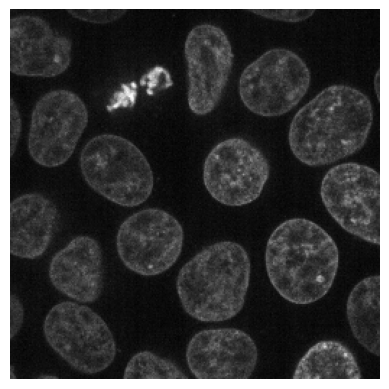

In [ ]:
tfm = RandRotate90(max_k=3, prob=1)
show_image(tfm(im));

In [ ]:
#| export
class RandFlip(RandMonaiTransform):
    """
    Randomly flips an ND image over a specified axis.
    Works with both NumPy arrays and BioImageBase objects.
    """
    _monai_rand_transform = mt.RandFlip
    _monai_det_transform = mt.Flip
        

In [ ]:
image = np.random.rand(1, 3, 3)  
flip_transform = RandFlip(prob=1., spatial_axis=0)  
flipped_image = flip_transform(image)
print('original:\n', image)
print('flipped:\n', flipped_image)  
test_eq(image[0,0,0], flipped_image[0,2,0]) # Check if the image is flipped correctly


original:
 [[[0.80485171 0.34638363 0.61595548]
  [0.24682597 0.67763938 0.6912715 ]
  [0.48665044 0.42575105 0.97663238]]]
flipped:
 metatensor([[[0.4867, 0.4258, 0.9766],
         [0.2468, 0.6776, 0.6913],
         [0.8049, 0.3464, 0.6160]]], dtype=torch.float64)


In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = BioImageBase(rand(*orig_size))
print('orig tensor: ', rand_tensor, '\n')
for i in range(3):
    print(RandFlip(prob=.75, spatial_axis=None)(rand_tensor))

orig tensor:  metatensor([[[0.7094, 0.0619, 0.5801, 0.4099],
         [0.7446, 0.4937, 0.0243, 0.1972],
         [0.7380, 0.0476, 0.0688, 0.1482],
         [0.0524, 0.1741, 0.9061, 0.7527]]]) 

metatensor([[[0.7527, 0.9061, 0.1741, 0.0524],
         [0.1482, 0.0688, 0.0476, 0.7380],
         [0.1972, 0.0243, 0.4937, 0.7446],
         [0.4099, 0.5801, 0.0619, 0.7094]]])
metatensor([[[0.7527, 0.9061, 0.1741, 0.0524],
         [0.1482, 0.0688, 0.0476, 0.7380],
         [0.1972, 0.0243, 0.4937, 0.7446],
         [0.4099, 0.5801, 0.0619, 0.7094]]])
metatensor([[[0.7094, 0.0619, 0.5801, 0.4099],
         [0.7446, 0.4937, 0.0243, 0.1972],
         [0.7380, 0.0476, 0.0688, 0.1482],
         [0.0524, 0.1741, 0.9061, 0.7527]]])


In [ ]:
#| export
class RandZoom(RandMonaiTransform):
    """
    Randomly zoom the input arrays with given probability within given zoom range.

    """

    _monai_rand_transform = mt.RandZoom
    _monai_det_transform = mt.Zoom

    def __init__(self,
                 prob=0.1,
                 min_zoom=0.9, 
                 max_zoom=1.1,
                 keys=None, 
                 **kwargs
                 ):

        super().__init__(
            keys=keys,
            prob=prob,
            min_zoom=min_zoom, 
            max_zoom=max_zoom,
            **kwargs,
        )

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):

        self.sampled_kwargs = {}

        min_zoom = self.kwargs["min_zoom"]
        max_zoom = self.kwargs["max_zoom"]

        if isinstance(min_zoom, Sequence):
            zoom_pairs = [
                (min_z,max_z) 
                for min_z,max_z in zip(
                    min_zoom, max_zoom
                    )
                ]
            sampled_zoom = tuple(
                self.param_sampler(v) for v in zoom_pairs
            )
            self.sampled_kwargs["zoom"] = sampled_zoom
        else:
            self.sampled_kwargs["zoom"] = self.param_sampler((min_zoom,max_zoom))

        # merge sampled into deterministic params
        self.sampled_kwargs = {
            **self.det_kwargs,
            **self.sampled_kwargs,
        }

In [ ]:
print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandZoom(prob=1)(rand_tensor))

orig tensor:  metatensor([[[0.7094, 0.0619, 0.5801, 0.4099],
         [0.7446, 0.4937, 0.0243, 0.1972],
         [0.7380, 0.0476, 0.0688, 0.1482],
         [0.0524, 0.1741, 0.9061, 0.7527]]]) 

metatensor([[[0.5024, 0.2900, 0.3029, 0.3029],
         [0.5060, 0.1586, 0.1096, 0.1096],
         [0.2530, 0.2991, 0.4689, 0.4689],
         [0.2530, 0.2991, 0.4689, 0.4689]]])
metatensor([[[0.7094, 0.0619, 0.5801, 0.4099],
         [0.7446, 0.4937, 0.0243, 0.1972],
         [0.7380, 0.0476, 0.0688, 0.1482],
         [0.0524, 0.1741, 0.9061, 0.7527]]])
metatensor([[[0.5024, 0.2900, 0.3029, 0.3029],
         [0.5060, 0.1586, 0.1096, 0.1096],
         [0.2530, 0.2991, 0.4689, 0.4689],
         [0.2530, 0.2991, 0.4689, 0.4689]]])


### Noise & Intensity Shift


In [ ]:
#| export
class RandCameraNoise(RandTransform):
    """
    Simulates camera noise with typedispatch support:
    - MetaTensor (kept in tensor domain)
    - dict (image key-based pipeline)
    - BioImageBase (type preserved)
    - NumPy arrays
    """

    def __init__(
        self,
        prob: float = 1.0,
        damp=1e-2,
        qe=0.7,
        gain=2,
        offset=100,
        exp_time=0.1,
        dark_current=0.6,
        readout=1.5,
        bitdepth=16,
        seed=42,
        simulation=False,
        camera='cmos',
        gain_variance=0.1,
        offset_variance=5,
        keys=None,  # <-- for dict support
    ):
        store_attr()
        self.p = prob
        self.rs = np.random.RandomState(seed=seed)

    # -------------------------
    # CORE NOISE FUNCTION 
    # -------------------------
    def _apply_noise(self, x, rs):
        max_adu = float(2**self.bitdepth - 1)

        # normalize input
        if x.min() >= 0.0 and x.max() <= 1.0:
            x = (x * max_adu).astype(np.uint16 if self.bitdepth > 8 else np.uint8)

        # photon model
        if not self.simulation:
            photons = x / self.gain / self.qe * self.damp
        else:
            photons = x

        photons = rs.poisson(photons, size=photons.shape)
        electrons = self.qe * photons

        # dark current
        electrons += rs.poisson(self.dark_current * self.exp_time, size=electrons.shape)

        # read noise (FIX: std should NOT be squared)
        electrons += rs.normal(scale=self.readout, size=electrons.shape) * (self.bitdepth / 16)

        gain = np.broadcast_to(self.gain, electrons.shape).astype(np.float32).copy()
        offset = np.broadcast_to(self.offset, electrons.shape).astype(np.float32).copy()

        if self.camera == 'cmos':
            gain_noise = rs.normal(scale=self.gain_variance, size=electrons.shape)
            offset_noise = (
                rs.normal(scale=self.offset_variance, size=electrons.shape)
                + rs.normal(scale=self.offset_variance, size=(electrons.shape[0],))
            )

            gain = gain + gain_noise
            offset = offset + offset_noise

        adu = electrons * gain + offset
        adu = np.clip(adu, 0, max_adu)

        return adu

    # -------------------------
    # MetaTensor
    # -------------------------
    def encodes(self, x: "MetaTensor"):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x, rs)
        return type(x)(out)

    # -------------------------
    # torch.Tensor
    # -------------------------
    def encodes(self, x: torchTensor):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x.numpy(), rs)
        return torch.as_tensor(out)

    # -------------------------
    # dict (MONAI-style)
    # -------------------------
    def encodes(self, x: dict):
        if self.keys is None:
            raise ValueError("keys must be provided for dict input")

        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))

        x = dict(x)  # avoid mutation
        for k in self.keys:
            x[k] = self._apply_noise(x[k], rs)

        return x

    # -------------------------
    # BioImageBase
    # -------------------------
    def encodes(self, x: BioImageBase):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x, rs)
        return type(x)(out)

    # -------------------------
    # NumPy
    # -------------------------
    def encodes(self, x: np.ndarray):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        return self._apply_noise(x, rs)

In [ ]:
img3 = img[30]

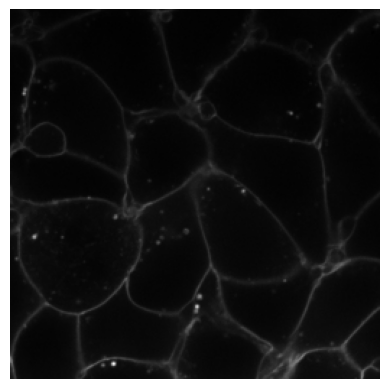

In [ ]:
# Original clean image
show_image(img3)

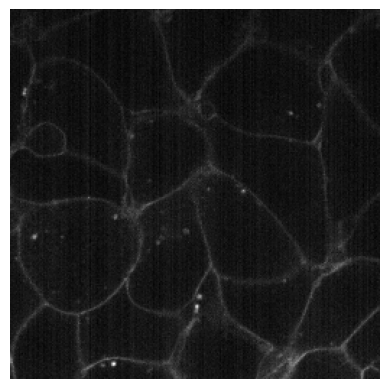

In [ ]:
# Noisy image simulating a CMOS camera
show_image(RandCameraNoise(camera = 'cmos').encodes(img3))

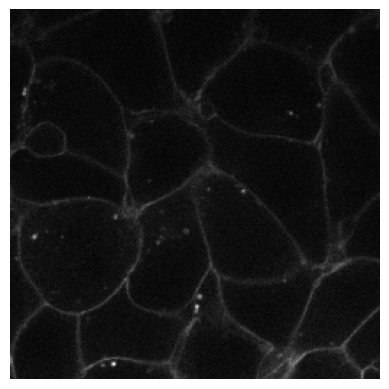

In [ ]:
# Noisy image simulating a CCD camera
show_image(RandCameraNoise(camera = 'ccd', readout=2).encodes(img3))

In [ ]:
#| export
class RandGaussianNoise(RandMonaiTransform):
    """
    Add Gaussian noise to image.
    """
    _monai_rand_transform = mt.RandGaussianNoise
    _monai_det_transform = mt.RandGaussianNoise

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        pass

    def encodes(self, x: BioImageBase):

        if self._rand_transform is None:
            self._build_rand_transform()

        out = self._rand_transform(x)

        return type(x)(
            x=out,
            meta=x.meta,
        )

In [ ]:
x =  [[1,1],[1,1]]
RandGaussianNoise(prob=1, std=5)(BioImageBase(x))

BioImageBase([[-2.8961,  2.6877],
        [ 5.4075,  0.1170]])

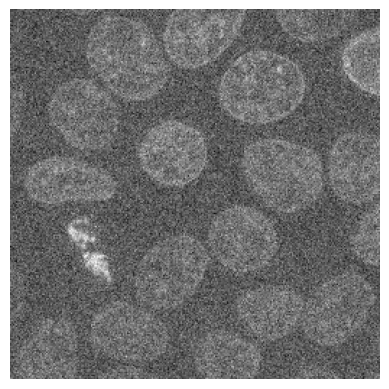

In [ ]:
show_image(RandGaussianNoise(prob=1, mean=100, std=10000)(BioImageBase(im)))

In [ ]:
#| export
class RandGaussianSmooth(RandMonaiTransform):
    """
    Apply Gaussian smoothing with randomly sampled sigma.
    """
    _monai_rand_transform = mt.RandGaussianSmooth
    _monai_det_transform = mt.GaussianSmooth

    _rand_kwargs = {'sigma': ['sigma_x', 'sigma_y']}

    def __init__(self, 
                 sigma_x=(0.25, 1.5), 
                 sigma_y=(0.25, 1.5), 
                 sigma_z=(0.25, 1.5), 
                 prob=0.1, 
                 param_sampler=_uniform_sampler, 
                 keys=None, 
                 **kwargs
                 ):
        super().__init__(prob=prob, 
                         param_sampler=param_sampler,
                         keys=keys, 
                         sigma_x=sigma_x,
                         sigma_y= sigma_y,
                         sigma_z=sigma_z, 
                         **kwargs)

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        if len(_get_sz(b)) == 3:
            self._rand_kwargs = {'sigma': ['sigma_x', 'sigma_y', 'sigma_z']}

        super().before_call(b, split_idx)

In [ ]:
#| export
RandBlur = RandGaussianSmooth

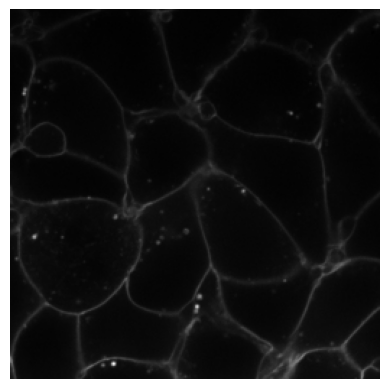

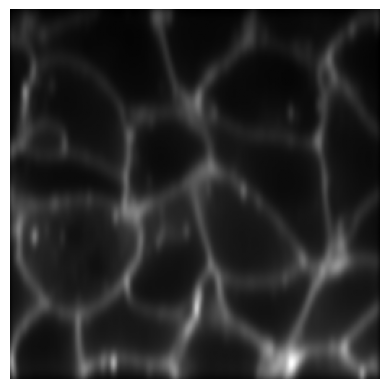

In [ ]:
# Apply Blur transform to the image
blur_transform = RandBlur(prob=1, sigma_x = (1.0, 5.0), sigma_y = (1, 5)) 
sharp_img = blur_transform(img)

# plot the original image
show_image(img)
# Plot the blurred image
show_image(sharp_img)

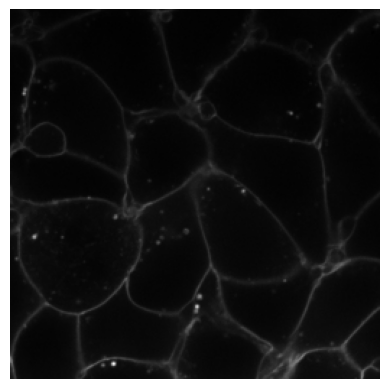

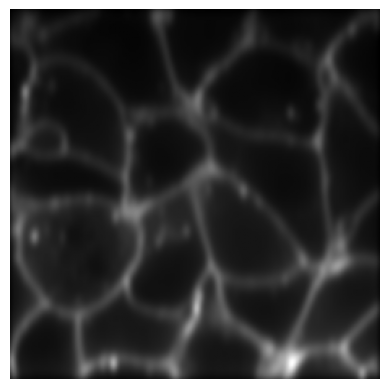

In [ ]:
# Apply Blur transform to the image
blur_transform = RandBlur((1.0, 5.0), (1.0, 5.0), prob = 1) 
blurred_img = blur_transform(MetaTensor(img))

# plot the original image
show_image(img)
# Plot the blurred image
show_image(blurred_img)

In [ ]:
#| export
class RandGaussianSharpen(RandMonaiTransform):
    """
    Randomly sharpen image using Gaussian kernels.
    """

    _monai_rand_transform = mt.RandGaussianSharpen
    _monai_det_transform = mt.GaussianSharpen

    _rand_kwargs = {'sigma1': ['sigma1_x', 'sigma1_y'],
                    'sigma2': ['sigma2_x', 'sigma2_y']
                    }

    def __init__(self, 
                sigma1_x=(0.5, 1.0), 
                sigma1_y=(0.5, 1.0), 
                sigma1_z=(0.5, 1.0), 
                sigma2_x=0.5, 
                sigma2_y=0.5, 
                sigma2_z=0.5,
                alpha=(10.0,30.0),
                **kwargs
                ):
        
        super().__init__(sigma1_x=sigma1_x,
                        sigma1_y= sigma1_y,
                        sigma1_z=sigma1_z, 
                        sigma2_x=sigma2_x, 
                        sigma2_y=sigma2_y, 
                        sigma2_z=sigma2_z,
                        alpha=alpha,
                        **kwargs)

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        if len(_get_sz(b)) == 3:
            self._rand_kwargs = {'sigma1': ['sigma1_x', 'sigma1_y', 'sigma1_z'],
                                'sigma2': ['sigma2_x', 'sigma2_y', 'sigma2_z']
                                }

        super().before_call(b, split_idx)

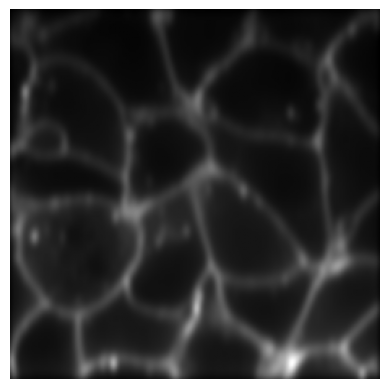

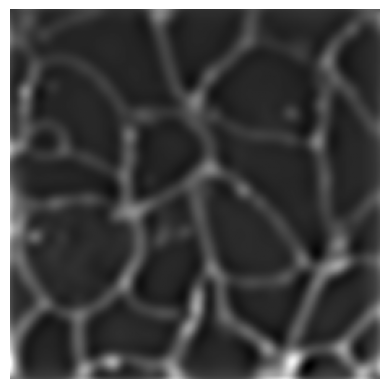

In [ ]:
# Apply Blur transform to the image
blur_transform = RandGaussianSharpen((1.0, 5.0), (1.0, 5.0), prob =1) 
sharp_img = blur_transform(blurred_img)

# plot the original image
show_image(blurred_img)
# Plot the blurred image
show_image(sharp_img)

In [ ]:
#| export
class RandShiftIntensity(RandMonaiTransform):
    """
    Randomly shift image intensity.

    Equivalent to MONAI RandShiftIntensity but uses the deterministic
    ShiftIntensity transform internally.
    """
    _monai_rand_transform = mt.RandShiftIntensity
    _monai_det_transform = mt.ShiftIntensity

    _rand_kwargs = {'offset': 'offsets'}

    def __init__(self,
                 offsets,
                 **kwargs,
                 ):

        super().__init__(
            offsets=offsets,
            **kwargs,
        )

class RandStdShiftIntensity(RandMonaiTransform):
    """
    Randomly shift intensity by a factor of the image standard deviation.
    """
    _monai_rand_transform = mt.RandStdShiftIntensity
    _monai_det_transform = mt.StdShiftIntensity

    _rand_kwargs = {'factor': 'factors'}

    def __init__(self,
                 factors,
                 **kwargs,
                 ):

        super().__init__(
            factors=factors,
            **kwargs,
        )

In [ ]:
#| export
class RandAdjustContrast(RandMonaiTransform):
    """
    Randomly adjust image contrast using gamma correction.
    """

    _monai_rand_transform = mt.RandAdjustContrast
    _monai_det_transform = mt.AdjustContrast

    _rand_kwargs = {'gamma': 'gamma'}

### Intensity Normalization

### Thresholding & Masking

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()